# SHAP — Explicabilidade de modelos

SHAP (SHapley Additive exPlanations) usa a teoria dos jogos cooperativos para medir a contribuicao de cada variavel em uma previsao.

A ideia central: o modelo e tratado como um "jogo" em que as variaveis cooperam para produzir a previsao. O valor de Shapley de uma variavel e a sua contribuicao media quando ela "entra no jogo" em todas as ordens possiveis.

Na pratica, o SHAP responde duas perguntas:
- **Globalmente**: quais variaveis mais influenciam o modelo?
- **Individualmente**: por que o modelo deu essa previsao para esse ponto especifico?

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

## Dataset

Usamos o dataset `diabetes` do sklearn:
- 442 pacientes
- 10 variaveis: idade, sexo, IMC, pressao arterial e medidas sericas
- Alvo: progressao da doenca (valor numerico)

As variaveis ja vem normalizadas (media zero, desvio padrao unitario).

In [3]:
dados = load_diabetes()
X = pd.DataFrame(dados.data, columns=dados.feature_names)
y = pd.Series(dados.target, name="progressao")

print(X.shape)
X.head()

(442, 10)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


## Treino e teste

Separamos 80% para treino e 20% para teste. Usamos uma Random Forest pequena — o TreeExplainer do SHAP e muito rapido para modelos baseados em arvores e nao precisa de nenhuma amostra de fundo.

In [4]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.15, random_state=42
)

modelo = RandomForestRegressor(
    n_estimators=100,
    n_jobs=-1,
    max_depth=3,
    random_state=42,
    max_features="sqrt",
)
modelo.fit(X_treino, y_treino)

pred_teste = modelo.predict(X_teste)
print(f"MAE: {mean_absolute_error(y_teste, pred_teste):.2f}")
print(f"R²:  {r2_score(y_teste, pred_teste):.3f}")

MAE: 45.18
R²:  0.432


## Calculando os valores SHAP

O `TreeExplainer` percorre a estrutura das arvores diretamente, sem precisar de amostras de fundo. Isso o torna muito mais rapido do que o `KernelExplainer` (que e model-agnostic mas caro).

O resultado e um objeto `Explanation` com:
- `.values`: valor SHAP de cada variavel para cada ponto — shape `(n_amostras, n_variaveis)`
- `.base_values`: previsao base (media do conjunto de treino), uma por amostra
- `.data`: os valores originais das variaveis

A propriedade fundamental do SHAP e a **aditividade**: `previsao = base_value + soma dos valores SHAP`.

In [5]:
explainer = shap.TreeExplainer(modelo)
shap_values = explainer(X_teste)

print("Formato dos valores SHAP:", shap_values.values.shape)
print(f"Previsao base:           {shap_values.base_values[0]:.2f}")

i = 0
soma_shap = shap_values.base_values[i] + shap_values.values[i].sum()
print(f"\nPonto {i}:")
print(f"  base + soma(SHAP) = {soma_shap:.2f}")
print(f"  modelo.predict    = {pred_teste[i]:.2f}")

Formato dos valores SHAP: (67, 10)
Previsao base:           152.66

Ponto 0:
  base + soma(SHAP) = 159.38
  modelo.predict    = 159.38


### Lendo o output

**`(67, 10)`** — formato da matriz de valores SHAP. Sao 67 amostras no conjunto de teste e 10 colunas, uma por feature. Cada celula `[i, j]` responde: "quanto a feature `j` empurrou a previsao do ponto `i` pra cima ou pra baixo?"

**`152.66`** — a previsao base. O TreeExplainer calcula esse valor percorrendo a estrutura de cada arvore e ponderando o valor de cada folha pelo numero de amostras de bootstrap que passaram por ela — nao e a mesma coisa que `mean(model.predict(X_treino))`, que passaria cada ponto pelo modelo e tiraria a media. A diferenca existe porque cada arvore da Random Forest foi treinada num subconjunto aleatorio do treino (bootstrap), entao as ponderacoes internas nao refletem exatamente a distribuicao completa do treino. Na pratica, o base value fica proximo de `y_treino.mean()` mas pode diferir um pouco.

**`base + soma(SHAP) = previsao`** — essa e a propriedade fundamental do SHAP, a aditividade. Cada valor SHAP e um "empurrao" em relacao a base: positivo puxa a previsao pra cima, negativo puxa pra baixo. A soma de todos esses empurroes mais a base bate exatamente com o que o modelo previu. O waterfall vai mostrar isso visualmente.

## Importancia global — bar plot

A media dos valores absolutos de SHAP de cada variavel mostra o quanto ela influencia o modelo em geral.

**Como ler:**
- As features estao ordenadas da mais para a menos importante (de cima pra baixo)
- O eixo X e a media de `|SHAP|` no conjunto de teste — quanto maior a barra, mais essa feature mexe na previsao em media
- O bar plot so mostra **magnitude**, nao direcao: nao da pra saber se a feature aumenta ou diminui a previsao, apenas que ela influencia bastante

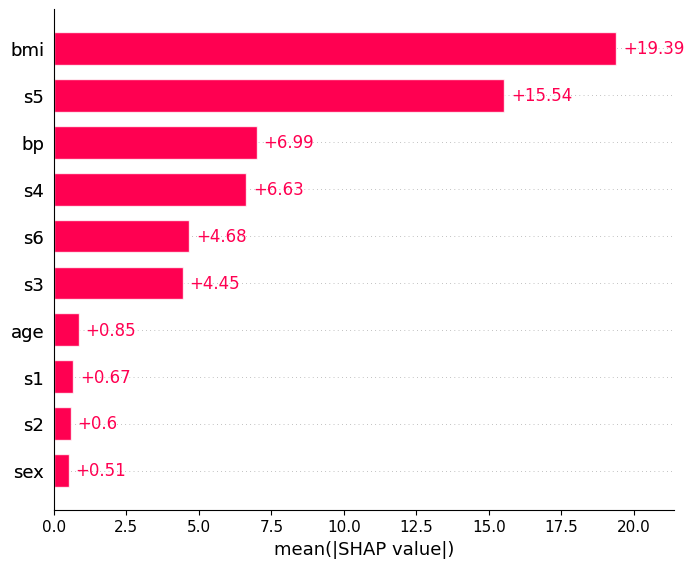

In [6]:
shap.plots.bar(shap_values)

## Beeswarm — importancia e direcao

O beeswarm combina tudo em um so grafico: ranking de importancia, magnitude do efeito e direcao.

**Estrutura:**
- Cada **linha** e uma feature, ordenada pela importancia media (igual ao bar plot)
- Cada **ponto** e uma amostra do conjunto de teste espalhada verticalmente para nao sobrepor (dai o nome "beeswarm" — parece um enxame)
- **Eixo X** = valor SHAP: o quanto aquela feature empurrou a previsao daquela amostra
- **Cor** = valor original da feature naquela amostra (azul = valor baixo, vermelho = valor alto)

**Como interpretar uma linha:**

Olhe para a linha do `bmi`. Se os pontos **vermelhos** (IMC alto) estao concentrados do lado **direito** (SHAP positivo) e os **azuis** (IMC baixo) estao do lado **esquerdo** (SHAP negativo), isso significa que IMC alto aumenta a previsao de progressao da doenca e IMC baixo diminui. O efeito e claro e consistente.

Agora compare com uma feature menos importante, como `age`. Se os pontos vermelhos e azuis ficam misturados dos dois lados, o efeito daquela feature no modelo e fraco ou inconsistente — ela nao tem uma relacao clara com o alvo.

**Largura da nuvem:** features com nuvens muito largas (pontos espalhados longe do zero) mexem muito na previsao. Features com nuvens estreitas perto do zero contribuem pouco, independente da cor.

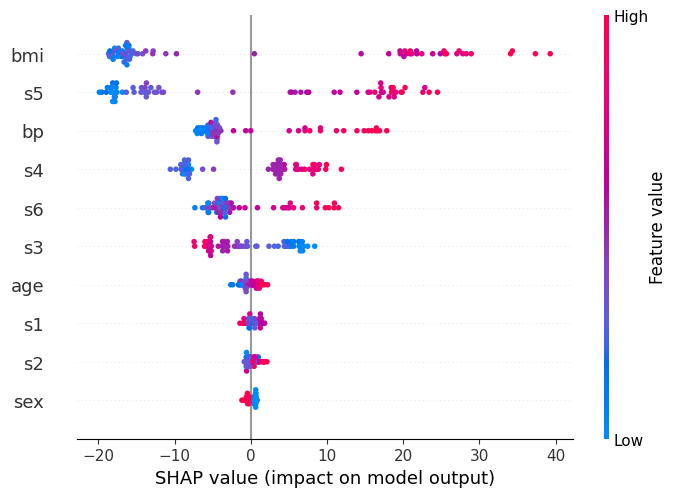

In [7]:
shap.plots.beeswarm(shap_values)

## Waterfall — explicando uma previsao individual

O waterfall mostra como cada variavel contribuiu para chegar na previsao de **um unico ponto**, partindo da previsao base ate a previsao final.

**Como ler:**
- O grafico comeca em `E[f(x)]`, a previsao base (media do treino)
- Cada barra e o valor SHAP de uma feature para esse ponto especifico
- **Barras vermelhas** (positivas) empurram a previsao pra cima
- **Barras azuis** (negativas) empurram a previsao pra baixo
- O valor a direita de cada barra e o SHAP daquela feature
- O valor a esquerda (ex: `bmi = 0.06`) e o valor real daquela feature para esse ponto
- O grafico termina em `f(x)`, que e a previsao final do modelo

A soma de todas as barras mais a base deve dar exatamente `f(x)` — a aditividade que verificamos no passo anterior.

y real:   70.0
previsao: 156.9


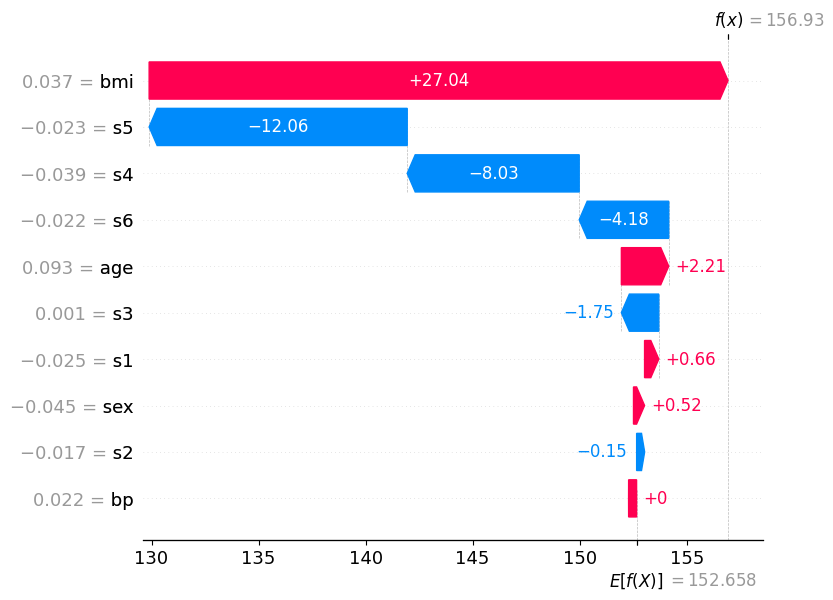

In [8]:
i = 1
print(f"y real:   {y_teste.iloc[i]:.1f}")
print(f"previsao: {pred_teste[i]:.1f}")

shap.plots.waterfall(shap_values[i])

## Scatter — efeito de uma variavel

O scatter mostra, para uma feature especifica, como o seu valor se relaciona com o seu valor SHAP em todas as amostras do conjunto de teste. E uma forma de ver o efeito que o modelo aprendeu para essa feature.

**Como ler:**
- **Eixo X** = valor original da feature (ex: IMC do paciente)
- **Eixo Y** = valor SHAP daquela feature (o quanto ela empurrou a previsao)
- Cada ponto e uma amostra
- **Tendencia de subida** = quanto maior o valor da feature, mais ela aumenta a previsao
- **Tendencia de descida** = efeito inverso
- **Curva nao-linear** = o efeito muda dependendo do valor (ex: nenhum efeito ate um limiar, depois cresce rapido)
- **Pontos espalhados verticalmente** para um mesmo X = o efeito da feature depende de outras variaveis (interacao)

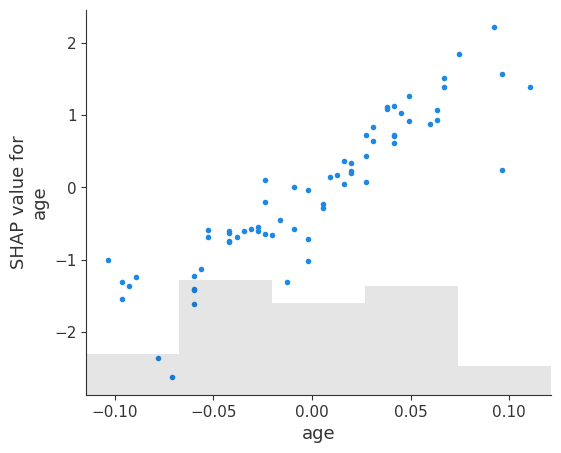

In [9]:
shap.plots.scatter(shap_values[:, "age"])

## Resumindo

- O **TreeExplainer** e rapido para Random Forest e Gradient Boosting — percorre as arvores diretamente em vez de estimar por amostragem.
- O **bar plot** mostra quais variaveis mais importam globalmente (media dos |SHAP|).
- O **beeswarm** adiciona a direcao do efeito e a distribuicao de cada variavel.
- O **waterfall** explica uma previsao individual — util para depuracao e comunicacao.
- O **scatter** mostra o efeito nao-linear de uma variavel especifica e possibilita ver interacoes.

A partir daqui da para trocar o modelo (XGBoost, LightGBM), trocar o dataset ou usar o `KernelExplainer` para modelos sem suporte a TreeExplainer (como KNN ou SVM) — mas aí o custo computacional sobe bastante.